## Setup environment

In [1]:
import arviz as az
import bambi as bmb
import numpy as np
import pandas as pd
import seaborn as sns
import pangolin as pg
import pangolin.interface as pi
import matplotlib.pyplot as plt

## Load data

In [2]:
data = bmb.load_data('sleepstudy')

data.head()

,Reaction,Days,Subject
0,249.5600,0,308
1,258.7047,1,308
2,250.8006,2,308
3,321.4398,3,308
4,356.8519,4,308


## Specify and fit model to data using `bambi`

In [3]:
model = bmb.Model('Reaction ~ 1 + Days + (1 + Days | Subject)', data)

model

       Formula: Reaction ~ 1 + Days + (1 + Days | Subject)
        Family: gaussian
          Link: mu = identity
  Observations: 180
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 298.5079, sigma: 261.0092)
            Days ~ Normal(mu: 0.0, sigma: 48.8915)
        
        Group-level effects
            1|Subject ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 261.0092))
            Days|Subject ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 48.8915))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 56.1721)

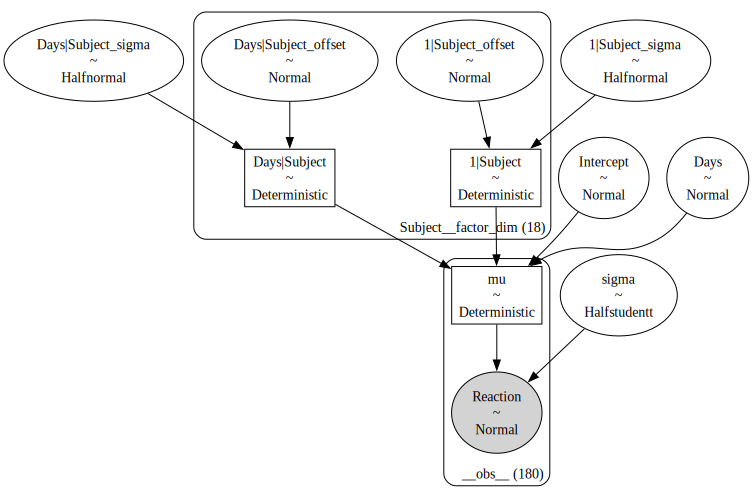

In [4]:
model.build()

model.graph()

In [5]:
post = model.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, Days, 1|Subject_sigma, 1|Subject_offset, Days|Subject_sigma, Days|Subject_offset]
/Users/marcoe02/src/playing_with_a_pangolin/.pixi/envs/default/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/marcoe02/src/playing_with_a_pangolin/.pixi/envs/default/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [6]:
az.summary(post)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,25.854,1.590,22.890,28.918,0.027,0.024,3426.0,3113.0,1.0
Intercept,251.409,7.662,235.950,265.076,0.141,0.121,2988.0,2797.0,1.0
Days,10.493,1.655,7.484,13.693,0.038,0.030,1906.0,2032.0,1.0
1|Subject_sigma,27.310,6.715,15.835,39.836,0.146,0.138,2230.0,2346.0,1.0
Days|Subject_sigma,6.543,1.473,4.154,9.374,0.034,0.031,1884.0,2083.0,1.0
1|Subject[308],1.557,13.943,-23.636,28.817,0.196,0.201,5047.0,3124.0,1.0
1|Subject[309],-40.283,14.188,-67.139,-14.113,0.194,0.201,5351.0,3434.0,1.0
1|Subject[310],-39.447,14.334,-65.287,-11.867,0.197,0.231,5240.0,2801.0,1.0
1|Subject[330],24.979,14.154,-2.432,50.969,0.220,0.227,4167.0,2980.0,1.0
1|Subject[331],23.298,13.981,-2.963,49.111,0.209,0.211,4498.0,3380.0,1.0


array([[<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'Days'}>,
        <Axes: title={'center': 'Days'}>],
       [<Axes: title={'center': '1|Subject_sigma'}>,
        <Axes: title={'center': '1|Subject_sigma'}>],
       [<Axes: title={'center': 'Days|Subject_sigma'}>,
        <Axes: title={'center': 'Days|Subject_sigma'}>],
       [<Axes: title={'center': '1|Subject'}>,
        <Axes: title={'center': '1|Subject'}>],
       [<Axes: title={'center': 'Days|Subject'}>,
        <Axes: title={'center': 'Days|Subject'}>]], dtype=object)

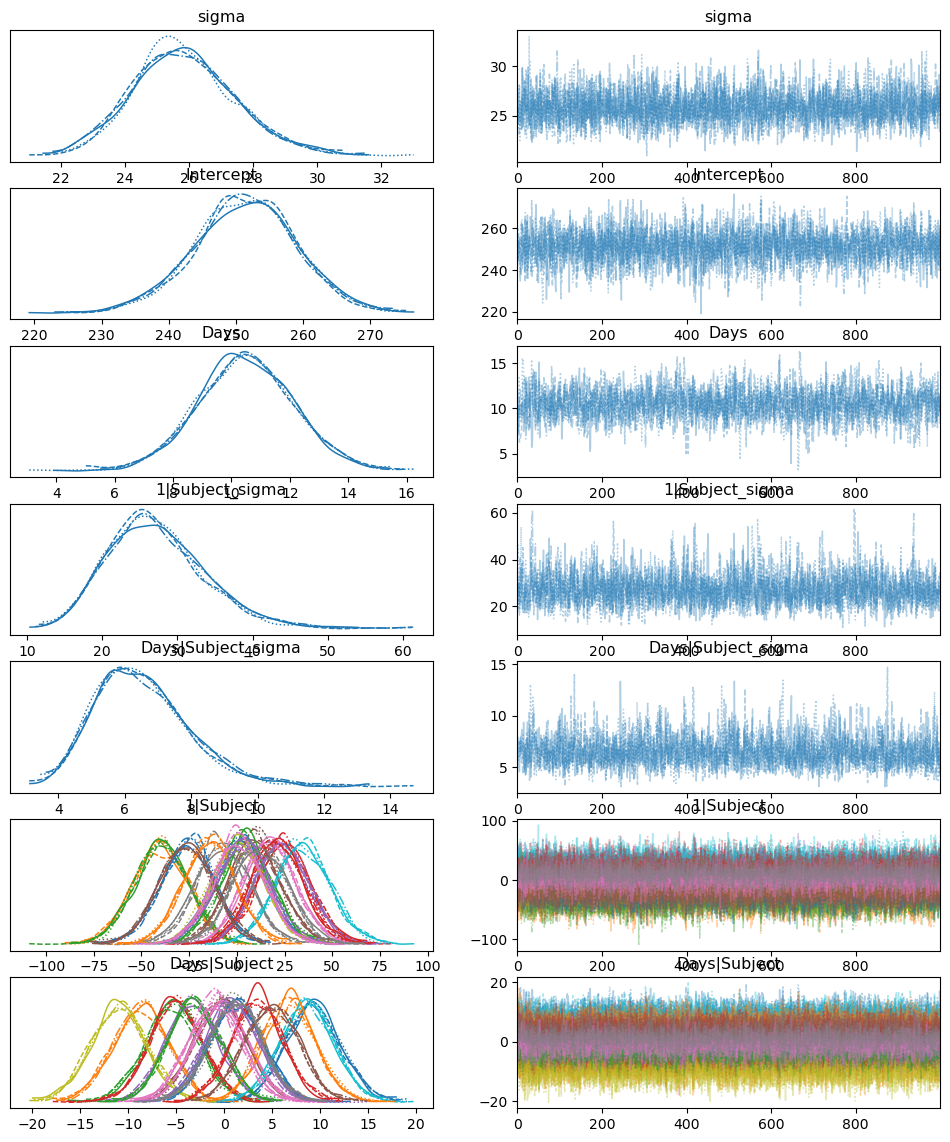

In [7]:
az.plot_trace(post)

## Specify and fit model using `pangolin`

In [8]:
data['SubjectIdx'] = pd.factorize(data['Subject'])[0]

In [9]:
α = pi.normal(100, 100)
β = pi.normal(0, 10)
σ = pi.exponential(0.01)
σ_a = pi.exponential(0.1)
σ_b = pi.exponential(0.1)
a = pi.vmap(lambda i: pi.normal(0, σ_a))(data.SubjectIdx.unique())
b = pi.vmap(lambda i: pi.normal(0, σ_b))(data.SubjectIdx.unique())
μ = pi.vmap(lambda x, i: (α + a[i]) + (β + b[i]) * x)(data.Days, data.SubjectIdx)
Reaction = pi.vmap(lambda mu: pi.normal(mu, σ))(μ)

In [10]:
post = pg.blackjax.sample_arviz({ 'α' : α, 'β' : β, 'σ' : σ, 'σ_a' : σ_a, 'σ_b' : σ_b }, Reaction, data.Reaction)

In [11]:
az.summary(post)

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,250.755,6.769,237.013,263.437,0.268,0.229,662.0,531.0,NaN
β,10.190,1.684,6.948,13.151,0.083,0.088,444.0,490.0,NaN
σ,25.902,1.524,23.164,28.796,0.042,0.047,1301.0,673.0,NaN
σ_a,24.035,5.497,14.199,33.702,0.199,0.178,757.0,868.0,NaN
σ_b,6.387,1.404,4.014,8.923,0.042,0.060,1210.0,736.0,NaN


array([[<Axes: title={'center': 'α'}>, <Axes: title={'center': 'α'}>],
       [<Axes: title={'center': 'β'}>, <Axes: title={'center': 'β'}>],
       [<Axes: title={'center': 'σ'}>, <Axes: title={'center': 'σ'}>],
       [<Axes: title={'center': 'σ_a'}>, <Axes: title={'center': 'σ_a'}>],
       [<Axes: title={'center': 'σ_b'}>, <Axes: title={'center': 'σ_b'}>]],
      dtype=object)

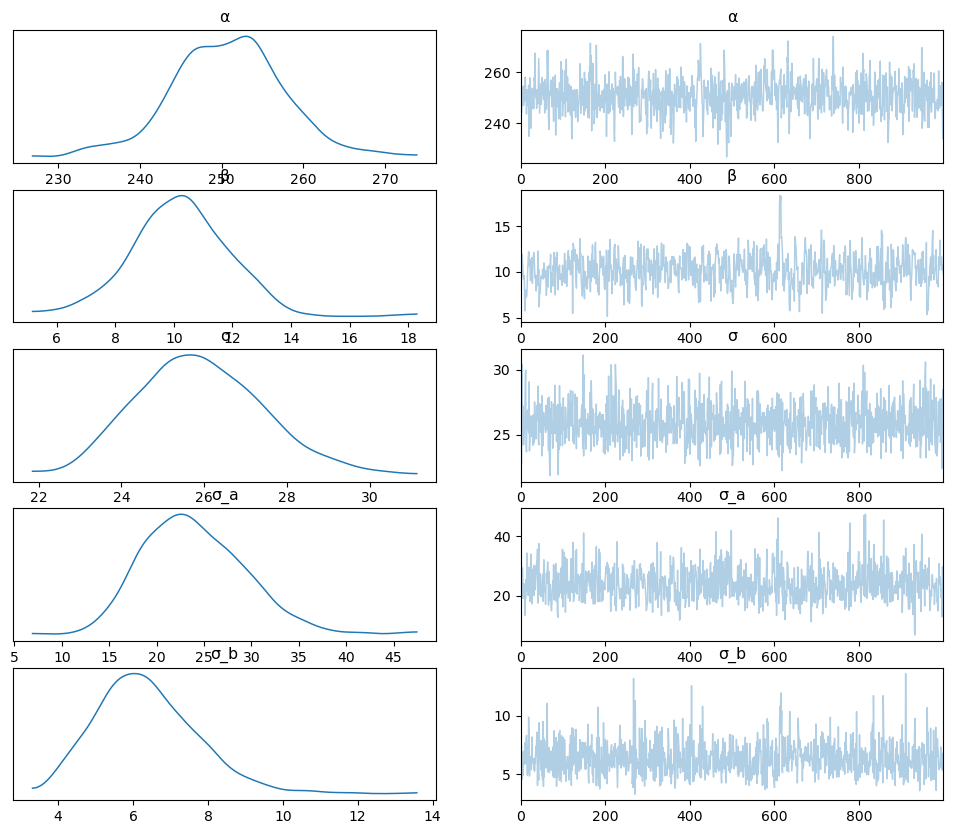

In [12]:
az.plot_trace(post)